# FX Pairs: Feature Engineering

Twenty currency pairs, one decision a day, taken at the New York 5PM close. Every column below
answers one question: at the moment the position is decided, which bars are already on the tape,
and what does the feature make of them?

## Learning objectives

- State a feature's timing contract - lookback and information lag - before writing its code
- Aggregate intraday bars onto the decision calendar so a daily feature ends at the snapshot it
  is decided on, and no later
- Show that withholding later dates leaves every value unchanged, which separates a trailing
  statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.2-8.4. Reads four-hour OANDA spot bars via `load_fx_pairs()` and
`config/setup.yaml`. Writes `features/financial.parquet` with a `.digest.json` sidecar, read by
[`05_evaluation`](05_evaluation.ipynb), which joins it to the fold-aware features
[`04_model_based_features`](04_model_based_features.ipynb) builds from the same prices and tests
fold by fold whether any of it predicts, and by
[`12_model_analysis`](12_model_analysis.ipynb), which reads it back to attribute what a fitted
model used.

In [1]:
"""FX Pairs: Feature Engineering."""

import warnings
from datetime import date

import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from ml4t.engineer.features.momentum import rsi
from ml4t.engineer.features.volatility.garman_klass_volatility import garman_klass_volatility

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    drawdown_block,
    families_from_config,
    family_coverage,
    momentum_volatility_block,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    warmup_audit,
)
from data import load_fx_pairs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("fx_pairs")
FEATURES_DIR = CASE_DIR / "features"

In [2]:
# Production runs START_DATE as None, taking the full OANDA history; CI overrides it to pin the
# window of the reduced fixture. There is no symbol cap: the ranked families need a cross-section
# to rank within, and this universe is twenty pairs wide to begin with.
START_DATE = None

## Configuration

Every window, the ranked list, the null-policy carrier, the session calendar and the holdout
boundary are declared in `config/setup.yaml` and bound here. A number the notebook invents is a
second source of truth for a decision the rest of the pipeline reads from one place.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FAMILIES = families_from_config(setup)
WINDOWS = setup["features"]["windows"]
RANKED = setup["features"]["ranked"]
CARRIER = setup["features"]["null_policy_carrier"]
PERSISTENCE_HORIZON = setup["features"]["persistence_horizon"]
SESSION_CALENDAR = setup["decision"]["session_calendar"]
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
CYCLE = int(resolve_label_horizon("fx_pairs", setup["labels"]["primary"], setup).rstrip("Dd"))

print(f"{len(FAMILIES)} declared families, decision cycle {CYCLE} session(s)")
print(f"Holdout starts {HOLDOUT_START}; Section D rebuilds the panel without it")

8 declared families, decision cycle 1 session(s)
Holdout starts 2024-01-01; Section D rebuilds the panel without it


## A. What the thesis says should carry information

The strategy is a long-short rank rebalance over twenty pairs, so the hypothesis has to be a
cross-sectional one: a pair stretched against its own recent range comes back relative to the
rest, and how far it can stretch depends on the state the market is in.

The **carrier** is the trailing z-score of a multi-horizon return and the position of price in
its own trailing channel. Which horizon the effect lives at is an empirical question, so the
matrix carries three of each, alongside the returns they are standardized from - mean reversion
and momentum are the same measurement read with opposite sign. The **conditioning** is state:
volatility, distance below a trailing peak, the width of the daily range, the broad dollar.
These rank nothing against each other; they say which environment a ranking is formed in, which
is what the register's `role` column records and what no assertion can recover from the values.
The **representation** matters as much as the quantity, so eight carrier and state columns are
also carried as percentiles within the decision date, comparable across dates by construction.

The register is declared in `config/setup.yaml`, one row per family: what it reads, how far
back, with what delay. Every lag is zero, and here that is a claim about the calendar rather
than about the vendor - Section B is where it is earned.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "driver hypothesis", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,driver hypothesis,inputs,lookback (bars),lag (bars),frame
str,str,str,str,i64,i64,str
"""momentum""","""signal""","""A pair that has moved keeps mo…","""daily close""",252,0,"""time series"""
"""risk-adjusted momentum""","""signal""","""Trend earned with less dispers…","""daily log return""",252,0,"""time series"""
"""mean reversion""","""signal""","""A pair stretched against its o…","""daily close""",378,0,"""time series"""
"""volatility""","""state""","""Dispersion sets how far apart …","""daily OHLC""",252,0,"""time series"""
"""range and drawdown""","""state""","""How far a pair sits below its …","""daily OHLC""",63,0,"""time series"""
"""oscillator and trend""","""signal""","""Price against its own recent p…","""daily close""",252,0,"""time series"""
"""dollar factor""","""state""","""A broad dollar move is common …","""daily returns of the seven USD…",315,0,"""cross-asset"""
"""cross-sectional position""","""signal""","""Only relative standing is trad…","""ret_21d, ret_63d, ret_126d, vo…",252,0,"""cross-section"""


## B. Inputs and their observability

Spot FX runs continuously from Sunday evening to Friday evening, so a "day" is a convention
rather than a fact, and the convention has to be the one the decision is taken on.
`config/setup.yaml` fixes it at the New York 5PM rollover and names the venue calendar that
implements it - the same calendar `02_labels` aggregates on.

That aggregation is where a daily FX feature leaks if it is going to. A session is built from the
bars that print inside it and closes on the last of them; a bar one slot later is part of the next
session. It is that boundary, not the calendar date, that makes every feature below knowable at
the decision it is used for, so it is asserted rather than described. The session close is
therefore the last price that printed before the snapshot rather than a price stamped at it: on
US market holidays the feed thins out hours early and the close is whatever traded last, which is
the price a decision taken at the snapshot could actually have seen. The bar timestamp is kept as
`bar_ts` and the open and close are taken by sorting on it, because a group-by does not
contractually preserve row order.

In [5]:
bars = load_fx_pairs(frequency="4h", start_date=START_DATE).select(
    ["symbol", "timestamp", "open", "high", "low", "close", "volume"]
)
sessions = TradingCalendar(SESSION_CALENDAR).get_sessions(
    pd.DatetimeIndex(bars["timestamp"].to_pandas())
)
bars = (
    bars.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)
prices = (
    bars.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
        pl.col("bar_ts").max().alias("_last"),
    )
    .sort(["symbol", "timestamp"])
)
assert prices.filter(pl.col("_last").dt.date() > pl.col("timestamp")).height == 0, (
    "a session absorbed a bar dated after its own decision date"
)
# The Garman-Klass variance proxy is non-negative only for a bar whose high and low bracket its
# open and close. A malformed bar would make the window mean negative and its square root arrive
# as a silent null, so the input is checked here rather than the output guarded downstream.
assert prices.select(
    (
        (pl.col("high") >= pl.max_horizontal("open", "close"))
        & (pl.col("low") <= pl.min_horizontal("open", "close"))
    ).all()
).item(), "an OHLC bar does not bracket its own open and close"
prices = prices.drop("_last")
print(f"{len(prices):,} sessions over {prices['symbol'].n_unique()} pairs")
print(f"{prices['timestamp'].min()} to {prices['timestamp'].max()}")

77,480 sessions over 20 pairs
2011-01-03 to 2025-12-31


## C. Feature construction, one subsection per family

### C.1 Momentum, volatility and their differences

The trailing return, close-to-close volatility and risk-adjusted return block is shared with the
other panel case studies, which had computed it character for character with different
denominator guards between them. What stays here is specific to this universe: the skip-recent
window and the differences between horizons, which say whether a trend is accelerating.

In [6]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """The shared trailing block, plus the differences this case study builds on it."""
    df = momentum_volatility_block(
        df,
        entity="symbol",
        return_windows=WINDOWS["momentum"],
        volatility_windows=WINDOWS["close_to_close_volatility"],
        periods_per_year=PERIODS_PER_YEAR,
    ).rename({f"vol_{w}d": f"vol_cc_{w}d" for w in WINDOWS["close_to_close_volatility"]})
    held = pl.col("close").shift(WINDOWS["skip_recent"]).over("symbol")
    return df.with_columns(
        (held / pl.col("close").shift(252).over("symbol").clip(lower_bound=EPS) - 1).alias(
            "mom_skip_recent"
        ),
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("accel_21_63"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("accel_63_126"),
    )

### C.2 Garman-Klass volatility

Chapter 8 uses the Garman-Klass estimator here, because a spot bar carries a high and a low that
a close-to-close deviation throws away and the range is where most of an FX session's
information about dispersion sits. It is a library call rather than four lines: one name
computed two ways is how `vol_gk_63d` comes to mean two things across nine case studies. The two
ratios are the regime indicator - a short window against a longer one says whether dispersion is
rising or falling, which no single window can.

In [7]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Garman-Klass deviation at four windows, and the two ratios between them."""
    short, mid, long = (WINDOWS["garman_klass"][i] for i in (0, 1, -1))
    return df.with_columns(
        garman_klass_volatility(
            "open", "high", "low", "close", period=w, trading_periods=PERIODS_PER_YEAR
        )
        .over("symbol")
        .alias(f"vol_gk_{w}d")
        for w in WINDOWS["garman_klass"]
    ).with_columns(
        (pl.col(f"vol_gk_{short}d") / pl.col(f"vol_gk_{mid}d").clip(lower_bound=EPS)).alias(
            f"vol_ratio_{short}_{mid}"
        ),
        (pl.col(f"vol_gk_{mid}d") / pl.col(f"vol_gk_{long}d").clip(lower_bound=EPS)).alias(
            f"vol_ratio_{mid}_{long}"
        ),
    )

### C.3 Mean reversion: z-scores, channel position and Bollinger %B

The carrier family. Each multi-horizon return is standardized against its own trailing year, so
the z-score says how unusual the move is for that pair rather than how large it is in price
terms. Channel position and Bollinger %B ask the same question of the level instead of the
change: where price sits in the range it has recently traded through. All three are trailing
statistics within one pair, so nothing here is estimated across pairs or across the sample.

In [8]:
def mean_reversion_features(df: pl.DataFrame) -> pl.DataFrame:
    """Trailing z-scores of the multi-horizon returns, and two range positions."""
    bb, close = WINDOWS["bollinger"], pl.col("close")
    hi = {w: close.rolling_max(w).over("symbol") for w in WINDOWS["channel"]}
    lo = {w: close.rolling_min(w).over("symbol") for w in WINDOWS["channel"]}
    mid = close.rolling_mean(bb).over("symbol")
    sd = close.rolling_std(bb).over("symbol")
    return df.with_columns(
        *[
            rolling_zscore(f"ret_{h}d", WINDOWS["zscore"], "symbol").alias(f"zscore_{h}d")
            for h in WINDOWS["zscore_horizons"]
        ],
        *[
            ((close - lo[w]) / (hi[w] - lo[w]).clip(lower_bound=EPS)).alias(f"channel_pos_{w}d")
            for w in WINDOWS["channel"]
        ],
        pl.when(sd > 0).then((close - (mid - 2 * sd)) / (4 * sd)).alias(f"bollinger_pctb_{bb}d"),
    )

### C.4 Drawdown, range and oscillators

`max_dd_63d` is the share by which price sits below its highest close of the trailing quarter,
so it is zero at a new high and negative otherwise. That is the *current* drawdown and not the
worst peak-to-trough decline inside the window; the two are different statistics and the shared
helper names them apart. RSI uses Wilder's recursive average, the library's convention, which is
not the number a simple moving average of the same gains and losses produces.

In [9]:
def drawdown_range_and_oscillators(df: pl.DataFrame) -> pl.DataFrame:
    """Distance below the trailing peak, normalized range, RSI and trend ratios."""
    close = pl.col("close")
    rng = (pl.col("high") - pl.col("low")) / close.clip(lower_bound=EPS)
    return drawdown_block(df, entity="symbol", windows=WINDOWS["drawdown"]).with_columns(
        *[rng.rolling_mean(w).over("symbol").alias(f"avg_range_{w}d") for w in WINDOWS["range"]],
        *[rsi("close", period=p).over("symbol").alias(f"rsi_{p}d") for p in WINDOWS["rsi"]],
        *[
            (close / close.rolling_mean(w).over("symbol").clip(lower_bound=EPS) - 1).alias(
                f"price_to_ma_{w}d"
            )
            for w in WINDOWS["moving_average"]
        ],
    )

### C.5 The dollar factor

Seven of the twenty pairs quote against the dollar and share a common component that is not
pair-specific. The proxy is a signed average of those seven returns - signed because a rise in
`USD_JPY` and a rise in `EUR_USD` are opposite dollar moves - and the seven are identified from
the symbols themselves rather than from a list typed here, so the proxy follows the universe.

It is a transparent average and not an estimated factor: no loading is fitted and nothing is
regressed. The average is over log returns, so accumulating it over a horizon is a sum and the
aggregates are the proxy's own cumulative move rather than an approximation of one. Each pair's
exposure is a rolling correlation over the trailing year, reading the pair's history and the
proxy's, both ending at the decision. The frame is re-sorted after the join: a rolling window
reads row order rather than the timestamp column, and a join promises nothing about order.

In [10]:
def dollar_factor(df: pl.DataFrame) -> pl.DataFrame:
    """The signed dollar proxy at three horizons, and each pair's correlation with it."""
    base, quote = pl.col("symbol").str.head(3), pl.col("symbol").str.tail(3)
    signed = (
        df.filter((base == "USD") | (quote == "USD"))
        .with_columns(
            pl.when(base == "USD")
            .then(pl.col("log_return"))
            .otherwise(-pl.col("log_return"))
            .alias("_usd")
        )
        .group_by("timestamp")
        .agg(pl.col("_usd").mean().alias("usd_factor_1d"))
        .sort("timestamp")
    )
    signed = signed.with_columns(
        pl.col("usd_factor_1d").rolling_sum(h).alias(f"usd_factor_{h}d") for h in WINDOWS["dollar"]
    )
    return (
        df.join(signed, on="timestamp", how="left")
        .sort(["symbol", "timestamp"])
        .with_columns(
            pl.rolling_corr(
                pl.col(f"ret_{h}d"),
                pl.col(f"usd_factor_{h}d"),
                window_size=WINDOWS["dollar_exposure"],
            )
            .over("symbol")
            .alias(f"usd_beta_{h}d")
            for h in WINDOWS["dollar"]
        )
    )

### C.6 Cross-sectional position, and the whole construction

The ranked columns become percentiles within their own decision date. The strategy is long-short
over a ranking, so relative standing is what it can act on, and a percentile is comparable across
dates in a way a level is not. The partition is the decision timestamp and nothing else, so the
statistic reads twenty rows and no other date.

In [11]:
def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel.

    The last step converts NaN to null. Some library calls fill their warmup with NaN and
    others with null, and a NaN is a missing value dressed as a number: `is_not_null` reads
    it as present, so the warmup audit and the coverage figure would score an empty stretch
    as covered.
    """
    df = (
        df.pipe(momentum_features)
        .pipe(volatility_features)
        .pipe(mean_reversion_features)
        .pipe(drawdown_range_and_oscillators)
        .pipe(dollar_factor)
        .with_columns(
            cross_sectional_percentile(col, "timestamp").alias(f"rank_{col}") for col in RANKED
        )
    )
    return df.with_columns(pl.col(pl.Float32, pl.Float64).fill_nan(None))


EXCLUDED = {"symbol", "timestamp", "open", "high", "low", "close", "volume", "log_return"}
built = build_features(prices)
feature_cols = [c for c in built.columns if c not in EXCLUDED]
print(f"{len(built):,} sessions carrying {len(feature_cols)} features")

77,480 sessions carrying 53 features


## D. The timing contract

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a fixed
number of bars backward within one pair. A **cross-sectional** statistic - the percentiles and
the dollar proxy - is taken over the decision timestamp, so it reads every pair on that date and
no other. A **join** broadcasts the proxy back to the panel and is followed by an explicit sort,
so the rolling correlation that reads it sees the order it assumes.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill. The audit checks that
length rather than describing it: a column carrying a value before its window could have filled
is reading bars that do not exist, and that is what it raises on. The two longest are chains
rather than single windows - `zscore_126d` standardizes a return against a further year of them,
and `usd_beta_63d` correlates a horizon return over a year of sessions.

In [12]:
warmup_audit(
    built,
    {
        "zscore_126d": WINDOWS["zscore"] + WINDOWS["zscore_horizons"][-1],
        "usd_beta_63d": WINDOWS["dollar_exposure"] + WINDOWS["dollar"][-1],
        "ret_252d": WINDOWS["momentum"][-1],
        "sharpe_252d": WINDOWS["momentum"][-1],
        "vol_gk_252d": WINDOWS["garman_klass"][-1],
        "price_to_ma_252d": WINDOWS["moving_average"][-1],
        "channel_pos_126d": WINDOWS["channel"][-1],
        "max_dd_63d": WINDOWS["drawdown"][0],
        "rsi_14d": WINDOWS["rsi"][0],
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""zscore_126d""",378,378,true
"""usd_beta_63d""",315,315,true
"""ret_252d""",252,253,true
"""sharpe_252d""",252,253,true
"""vol_gk_252d""",252,252,true
"""price_to_ma_252d""",252,252,true
"""channel_pos_126d""",126,126,true
"""max_dd_63d""",63,63,true
"""rsi_14d""",14,15,true


### D.3 Withholding the holdout changes nothing

Trailing and within-date statistics share a property worth checking directly: recomputed on a
panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was applied
to. Building the panel twice and comparing tests the whole construction at once, every emitted
column rather than a sample, and does not depend on anyone having flagged the transform that
fits. A value on one side against a null on the other counts as a difference, which is the form
of failure a null-skipping comparison hides.

In [13]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(prices.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=["timestamp", "symbol"],
)
seal.filter(pl.col("column").is_in(["zscore_126d", "rank_ret_126d", "usd_beta_63d"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""zscore_126d""",67100,0,0.0
"""usd_beta_63d""",67100,0,0.0
"""rank_ret_126d""",67100,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Raw OHLC, volume and the intermediate log return are
excluded: they are the inputs the features are made of, and the log return dated `t` is the
primary label dated one session earlier, so a model handed it beside that label would be reading
an answer it was asked for one row before. The shortest trailing return the matrix ships spans a
trading week.

One null policy is applied once. A row is kept from the session the configured carrier can first
hold a value - the longest chain in the matrix - which is the point past which every family is
dense, and the assertion below makes that a fact rather than an intention.

In [14]:
features = (
    built.select(["timestamp", "symbol", *feature_cols])
    .drop_nulls(subset=[CARRIER])
    .sort(["timestamp", "symbol"])
)
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
assert features.null_count().sum_horizontal().item() == 0, "the null policy left a gap behind"
assignment = assign_families(feature_cols, FAMILIES)
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} pairs"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}")
print(f"null policy dropped {len(built) - len(features):,} warmup rows")
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

53 features, 69,940 rows, 20 pairs
2012-06-19 to 2025-12-31
null policy dropped 7,540 warmup rows


family,columns,role,representation
str,i64,str,str
"""momentum""",10,"""signal""","""simple return, and differences…"
"""risk-adjusted momentum""",7,"""signal""","""mean log return over its own d…"
"""mean reversion""",7,"""signal""","""trailing z-score, position in …"
"""volatility""",8,"""state""","""Garman-Klass and close-to-clos…"
"""range and drawdown""",3,"""state""","""share below the trailing peak,…"
"""oscillator and trend""",5,"""signal""","""Wilder-smoothed oscillator, ra…"
"""dollar factor""",5,"""state""","""signed average return, and eac…"
"""cross-sectional position""",8,"""signal""","""percentile within the decision…"


The matrix carries **53 features** on **69,940 rows** across **20 pairs**, from **2012-06-19** to
**2025-12-31**. The null policy costs **7,540 rows**, every one of them inside the warmup stretch
at the start of a pair's history.

### F1. Coverage through time

Drawn on the panel *before* the null policy, so the figure shows what the policy is for. Each
family climbs to complete coverage as its longest window fills, and the boundary marks the first
session the emitted matrix keeps. Every month of the emitted panel is complete for every family,
which is why the lines to the right of the boundary are flat: that stretch is the assertion above
drawn rather than asserted, and the ramp to its left is what the policy removes.

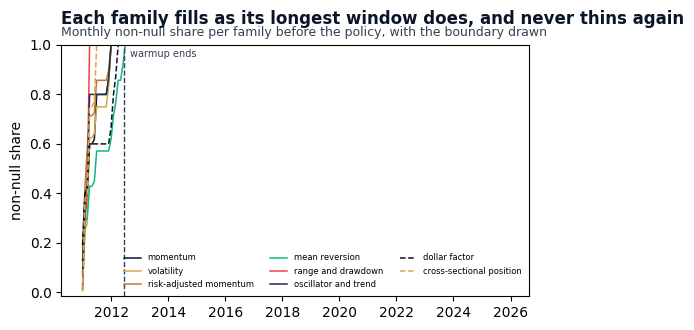

In [15]:
plot_coverage_through_time(
    family_coverage(built.select(["timestamp", *feature_cols]), assignment, every="1mo"),
    warmup_boundary=features["timestamp"].min(),
    title="Each family fills as its longest window does, and never thins again",
    subtitle="Monthly non-null share per family before the policy, with the boundary drawn",
    alt=(
        "Non-null share by feature family, on an axis from zero to one. Every family starts at "
        "zero and climbs to one during the first eighteen months as its longest window fills, "
        "the short-window families first and mean reversion last. A dashed line in mid-2012 marks "
        "where the null policy starts, and every line is flat at one from there to the end."
    ),
)

### F4. The timing contract

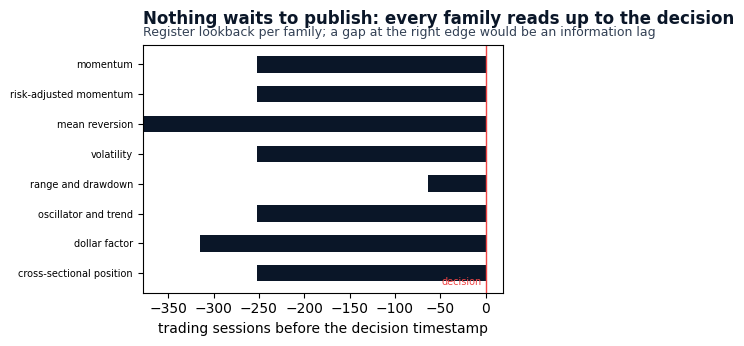

In [16]:
plot_timing_contract(
    FAMILIES,
    bar_unit="trading sessions",
    title="Nothing waits to publish: every family reads up to the decision",
    subtitle="Register lookback per family; a gap at the right edge would be an information lag",
    alt=(
        "Horizontal bars, one per family, each extending leftward from the decision line by that "
        "family's declared lookback - shortest for range and drawdown, longest for the dollar "
        "factor and mean reversion. Every bar reaches the line, so no family shows a lag gap."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. `05_evaluation` is where the matrix is tested fold by
fold for whether any of it predicts.

### F2. Feature distributions

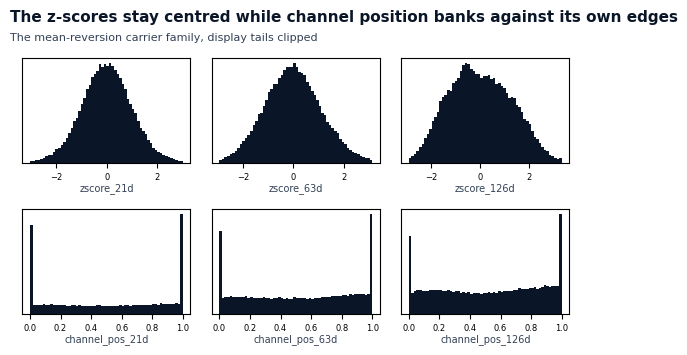

In [17]:
plot_feature_distributions(
    features,
    ["zscore_21d", "zscore_63d", "zscore_126d"] + [f"channel_pos_{w}d" for w in WINDOWS["channel"]],
    title="The z-scores stay centred while channel position banks against its own edges",
    subtitle="The mean-reversion carrier family, display tails clipped",
    alt=(
        "Six histograms in two rows. The top row holds the trailing z-scores of the three "
        "horizon returns, each a broad single-peaked body roughly centred on zero. The bottom row "
        "holds channel position at the same windows, bounded by zero and one with mass banked "
        "against both ends."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band narrows
to nothing there is nothing to rank, whatever the average level of the feature. That never
happens here, which is the necessary condition rather than a promising one: a band this wide says
a ranking exists to be formed, not that it predicts anything.

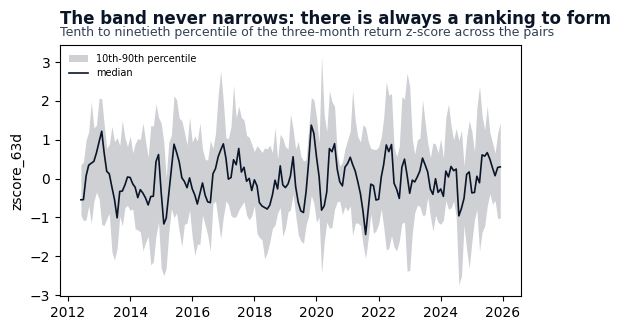

In [18]:
plot_cross_sectional_dispersion(
    features,
    "zscore_63d",
    every="1mo",
    title="The band never narrows: there is always a ranking to form",
    subtitle="Tenth to ninetieth percentile of the three-month return z-score across the pairs",
    alt=(
        "Shaded band of the tenth to ninetieth percentile of the three-month return z-score by "
        "month, with the median drawn through it. The band is between two and three units wide in "
        "every year of the sample and never approaches zero width. The median wanders within "
        "roughly plus or minus one and shows no trend."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate their
contributions. What the tree groups on is the horizon rather than the family: the short-window
return, its z-score, its channel position, its trend ratio, its oscillator and its two percentile
columns all land in one cluster, and the same happens again at the medium and long windows. The
volatility columns are the exception and cluster with each other across every window. What stays
out is worth as much as what joins - the dollar-factor aggregates, the two volatility ratios, the
two acceleration columns and the longest z-score are each alone above the cut, so they are the
only columns carrying an ordering nothing else in the matrix repeats. This states the clusters;
choosing one representative from each needs a fold-aware criterion and belongs to `05_evaluation`.

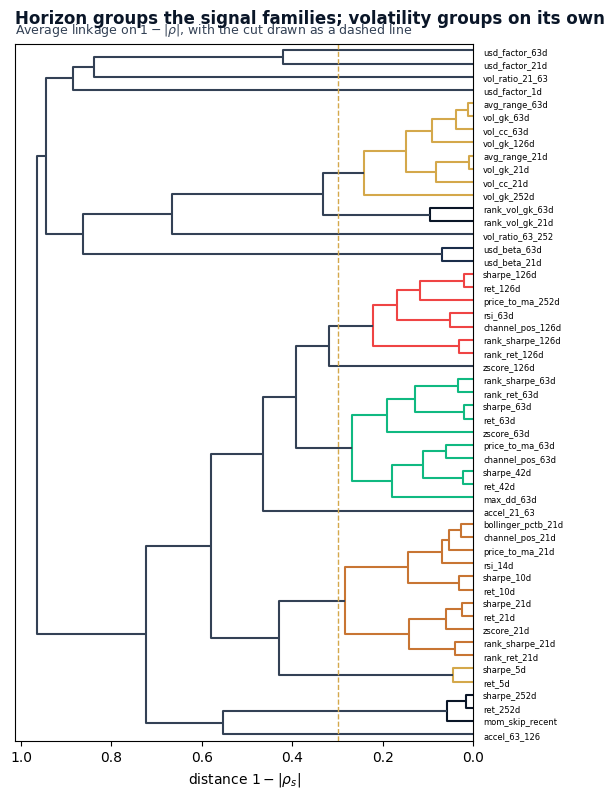

16 redundancy clusters at the drawn cut


In [19]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=0.7,
    title="Horizon groups the signal families; volatility groups on its own",
    subtitle=r"Average linkage on $1 - |\rho|$, with the cut drawn as a dashed line",
    alt=(
        "Dendrogram of every feature in the matrix. Three large clusters each hold one horizon "
        "and mix every signal family in it: the short-window return, z-score, channel position, "
        "trend ratio, oscillator and percentile columns join together, and the same happens at "
        "the medium and long windows. A fourth cluster holds the volatility columns from every "
        "window. The dollar-factor aggregates, the two volatility ratios, the two acceleration "
        "columns and the longest z-score each sit alone above the cut."
    ),
)
print(f"{len(set(clusters.values()))} redundancy clusters at the drawn cut")

Cutting the redundancy tree leaves **16 clusters** for **53 features**, so most of the matrix
repeats an ordering another column already carries.

### F6. Persistence and rank stability

The cadence is daily, so the right panel compares the ordering across consecutive sessions, the
schedule the strategy rebalances on. At that cadence the panel separates nothing - one session is
short enough that every feature keeps its ordering - and the left panel is what carries the
information: the autocorrelation of the feature itself, run out to a quarter. It is estimated per
pair on sessions exactly one lag apart and summarized by the median over pairs, with a bootstrap
interval over pairs; a correlation pooled over every pair-date would read high whenever pairs sit
at different levels, whether or not any one of them persists. Read that way the figure says which
columns are state and which are signal, and it puts the short z-score at zero at a lag equal to
its own window - a value that has nothing left to say about the one before it.

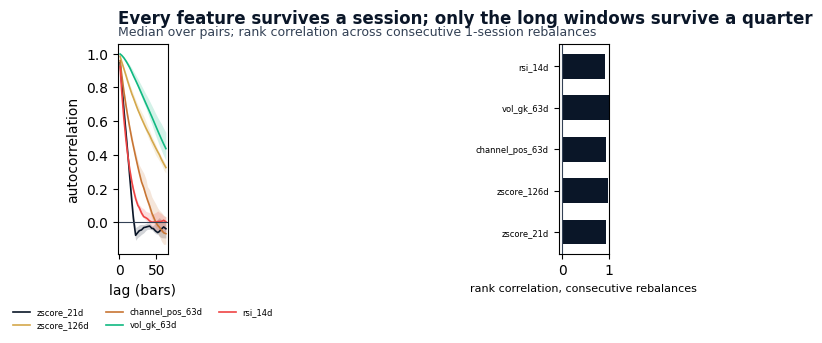

In [20]:
plot_persistence(
    features,
    ["zscore_21d", "zscore_126d", "channel_pos_63d", "vol_gk_63d", "rsi_14d"],
    entity="symbol",
    max_lag=PERSISTENCE_HORIZON,
    decision_dates=features["timestamp"].unique().sort().to_list(),
    title="Every feature survives a session; only the long windows survive a quarter",
    subtitle=f"Median over pairs; rank correlation across consecutive {CYCLE}-session rebalances",
    alt=(
        "Two panels. On the left, autocorrelation against lag out to a quarter. Three-month "
        "Garman-Klass volatility decays slowest and is still near a half at the right edge, the "
        "126-session z-score is around a third, and the 63-session channel position, the "
        "21-session z-score and the 14-day oscillator have all reached zero by then - the short "
        "z-score crossing zero at a lag equal to its own window and staying slightly negative. "
        "The bootstrap ribbons are narrow throughout. On the right, the cross-sectional rank "
        "correlation between consecutive sessions is close to one for all five features, with "
        "volatility highest and the oscillator lowest."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digest of what it was built from. The digest is over content rather than file
bytes, so row order and parquet metadata leave it alone and any feature value moves it. That is
the property the registry's own hashes lack: a feature-set *name* reaches the registry and a
feature-set *value* does not, so a corrected feature moves every number downstream without
changing anything the registry stores.

In [21]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/fx_pairs/03_financial_features.py",
    inputs={"load_fx_pairs:4h": value_digest(prices)},
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')} under digest {record['digest']}")

Wrote case_studies/fx_pairs/features/financial.parquet under digest 84aa1195f672ce0b


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **In a market that never closes, the aggregation is the timing contract.** A daily FX feature
  is knowable at its decision only because the session boundary is the same rollover the decision
  is taken at, which is why Section B asserts that boundary rather than describing it.
- **Test the seal by construction, not by inspection.** Rebuilding the panel with later dates
  withheld catches any transform fitted across the sample, including the ones nobody flagged.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- There is no carry feature, and carry is the most thoroughly documented effect in this asset
  class. It needs the interest-rate differential between the two legs, which the OANDA spot feed
  does not carry, so the matrix says nothing about the return a position earns for being held.
  Every conclusion drawn downstream is a conclusion about spot dynamics alone.
- The dollar proxy is an equal-weighted signed average of seven pairs, not an estimated factor.
  It says nothing about the euro or yen blocs, which the crosses here load on as heavily.
- Volume on a spot feed is tick count at one venue rather than traded notional, so it is used
  only through the daily range and not as a participation feature.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.